In [1]:
!pip show hiperwalk |head
!date

Name: hiperwalk
Version: 2.0rc1
Summary: High-Performance Quantum Walk Simulator
Home-page: 
Author: 
Author-email: Gustavo Bezerra <gbezerra@posgrad.lncc.br>, Paulo Motta <prmottajr@gmail.com>, Renato Portugal <portugal@lncc.br>, Eduardo Garcia <bidu@lncc.br>
License: GNU Lesser General Public License

_Version 3, 29 June 2007_  
ERROR: Pipe to stdout was broken
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Tue Mar 31 02:07:48 PM UTC 2026


In [2]:
import sys
print(sys.executable)
import numpy as np
import hiperwalk as hpw
print(hpw.__file__)
import hiperblas as hb
print(hb.__file__)
from datetime import datetime
import time

/opt/conda/bin/python
/home/jovyan/hiperwalk/hiperwalk/__init__.py
/home/jovyan/hiperwalk/pyhiperblas/hiperblas.cpython-311-x86_64-linux-gnu.so


## Coined quantum walk on the two-dimensional grid

In [3]:
#!echo $USER
#!date
#!pwd
#!cd ../../../../hiperblas-core;make clean; make install; ls -ltr
#!cd ../../../../pyhiperblas; pwd;  pip install --user .
#!cd ../../../../hiperwalk; pwd;  pip install --user hiperwalk



### Defining the graph and the QW instance

Let set $n$ for the two-dimensional square grid graph with $n^2$ vertices.

In [5]:
hb="y"
myHPC_option="cpu" if hb == "y" else None

hpw.set_hpc(myHPC_option)
dim = 16
aCoin="F"
numSteps=500; startStep=1; endStep=startStep+numSteps; step=1 

aRange=(startStep, endStep, step)


BD, em def set_hpc(hpc), hpc= cpu


The next command creates a grid, which is an instance of the Graph class.

In [6]:
inicioG = time.perf_counter()
g = hpw.Hypercube(dim)
fimG    = time.perf_counter()
print(f"Hypercube: Tempo decorrido: {fimG - inicioG:.6f} segundos", file=sys.stderr)

Hypercube: Tempo decorrido: 0.814684 segundos


The next command creates a QW on the grid, which is an instance of the Coined class.

In [7]:
inicioC = time.perf_counter()
qw = hpw.Coined(g, coin=aCoin)
fimC    = time.perf_counter()
print(f"computeU : Tempo decorrido: {fimC - inicioC:.6f} segundos", file=sys.stderr)



bd, em coined.py, __init__
graph: <hiperwalk.graph.graph.Graph object at 0x7f5fc33e8650>
kwargs: {'coin': 'F'}

_set_shift     :   Tempo decorrido: 1.480441 segundos

_set_coin      :   Tempo decorrido: 0.000098 segundos

_set_marked    :   Tempo decorrido: 0.000092 segundos
bd, em hiperwalk/quantum_walk/coined.py: def _set_evolution
BD, em hiperwalk/quantum_walk/coined.py: get_coin(self)
BD, em hiperblas_wrapper.c, py_sparse_matrix_new
BD, em /home/bidu/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c, smatrix_new
BD, em hiperblas_wrapper.c: static PyObject* py_smatrix_connect( ...
BD, em hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c: void smatreqdev(smatrix_t *m) {
BD, em hiperblas_wrapper.c, py_sparse_matrix_new
BD, em /home/bidu/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c, smatrix_new
BD, em hiperblas_wrapper.c: static PyObject* py_smatrix_connect( ...
BD, em hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c: void smatreqdev(smatrix_t *m) 

computeU : Tempo decorrido: 3.724214 segundos


In [8]:
    import os
    from pathlib import Path  # Import the Path class
    C = qw.get_evolution(); num_arcs=C.shape[0];  densidade=C.nnz/(num_arcs*num_arcs)


    coinT  = "Grover  coin,    real" if aCoin=="G"            else "Fourier coin, complex"
    algebra="SciPy"                  if myHPC_option == None else "HiperBlas"
    
    #nome=os.path.splitext(os.path.basename(__file__))[0] # sem extensão
    nome_do_notebook_completo = "meu_notebook.ipynb" # Ou você pode tentar obter isso do IPython
    nome = Path(nome_do_notebook_completo).stem
    print(
    f"{nome:14s}, "
    f"dim = {dim:4d}, "
    f"numStep = {endStep - startStep:4d}, "
    f"{coinT}, "
    f"numArcs = {num_arcs:10d}, "
    f"nnz = {C.nnz:12d}, "
    f"densidade = {densidade:.5e}, "
    f"algebra = {algebra:>10s}, "
    f"OMP_NUM_THREADS = {os.getenv('OMP_NUM_THREADS') or 'ND':>3s} ")
    print('\n')

meu_notebook  , dim =   16, numStep =  200, Fourier coin, complex, numArcs =    1048576, nnz =     16777216, densidade = 1.52588e-05, algebra =  HiperBlas, OMP_NUM_THREADS =  ND 




### Setting the initial state 

In [9]:
initialState = qw.state([[1, i] for i in range(dim)])

bd, em coined.py: def state


### Simulation 

In [10]:

print ("aRange=",aRange)
print(datetime.now())
inicioS = time.perf_counter()
for r in range(1): #50*1000*1000):
       states = qw.simulate(aRange, state=initialState)
fimS    = time.perf_counter()
print(f"Iteracoes: Tempo decorrido: {fimS - inicioS:.6f} segundos", file=sys.stderr)
print(datetime.now())


aRange= (1, 201, 1)
2026-01-14 16:16:31.321046
bd, em hiperwalk/quantum_walk/quantum_walk.py:    def simulate
bd, start=1, end=201, step=1
bd, em quantum_walk.py: def _prepare_engine(self, state, hpc =  cpu
bd, em simulate, initial state, state= [ 0.250+0.000j  0.250+0.000j  0.250+0.000j ...  0.000+0.000j  0.000+0.000j  0.000+0.000j];  BD, em /home/bidu/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-vector.c: vector_new
BD, em hiperblas_wrapper.c: py_vector_connect )
BD, em /home/bidu/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-vector.c: vector_new
BD, em hiperblas_wrapper.c: py_vector_connect )
BD, em hiperblas_wrapper.c, py_sparse_matrix_new
BD, em /home/bidu/hiperwalk/hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c, smatrix_new
BD, em hiperblas_wrapper.c: static PyObject* py_smatrix_connect( ...
BD, em hiperblas-core/src/libhiperblas-cpu-bridge-smatrix.c: void smatreqdev(smatrix_t *m) {
state.l2Norm= 1.0
bd, em def _simulate_step, step = 0
bd, em def simulate,   

WhileIt  : Tempo decorrido: 6.875432 segundos
Iteracoes: Tempo decorrido: 6.898256 segundos


In [11]:
    U = qw.get_evolution(); num_arcs=U.shape[0];  densidade=U.nnz/(num_arcs*num_arcs)
    import os
    from pathlib import Path  # Import the Path class

    coinT  = "Grover  coin,    real" if aCoin=="G"            else "Fourier coin, complex"
    algebra="SciPy"                  if myHPC_option == None else "HiperBlas"
    
    #nome=os.path.splitext(os.path.basename(__file__))[0] # sem extensão
    nome_do_notebook_completo = "meu_notebook.ipynb" # Ou você pode tentar obter isso do IPython
    nome = Path(nome_do_notebook_completo).stem
    print(
    f"{nome:14s}, "
    f"dim = {dim:4d}, "
    f"numStep = {endStep - startStep:4d}, "
    f"{coinT}, "
    f"numArcs = {num_arcs:10d}, "
    f"nnz = {U.nnz:12d}, "
    f"densidade = {densidade:.5e}, "
    f"algebra = {algebra:>10s}, "
    f"OMP_NUM_THREADS = {os.getenv('OMP_NUM_THREADS') or 'ND':>3s}, "
    f"tempo computeU = {fimC - inicioC:.5e}, "
    f"tempo Iteracoes = {(fimS - inicioS) / (endStep - startStep + 1):.5e}, "
    f"tempo total = {(fimS - inicioG) :.5e}")
    print('\n')

meu_notebook  , dim =   16, numStep =  200, Fourier coin, complex, numArcs =    1048576, nnz =     16777216, densidade = 1.52588e-05, algebra =  HiperBlas, OMP_NUM_THREADS =  ND, tempo computeU = 3.72421e+00, tempo Iteracoes = 3.43197e-02, tempo total = 2.77448e+01




### Probability distribution

In [14]:
probs = qw.probability_distribution(states)

bd, em coined.probability_distribution, 0
bd, em coined.probability_distribution, 1
bd, em coined.probability_distribution, 5


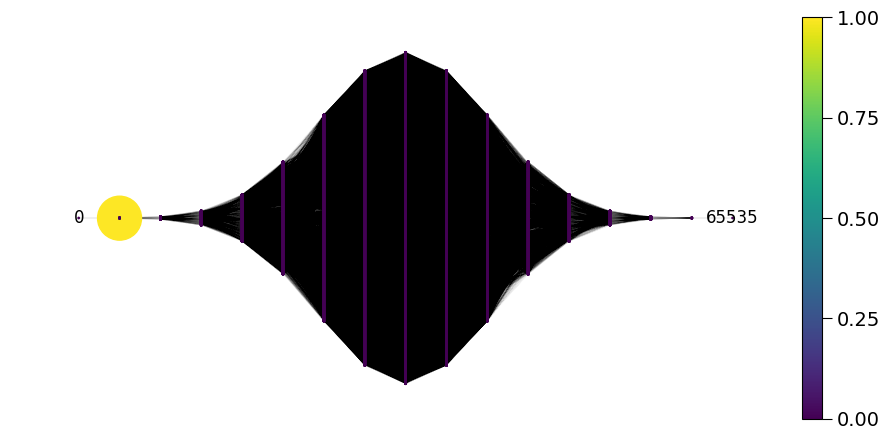

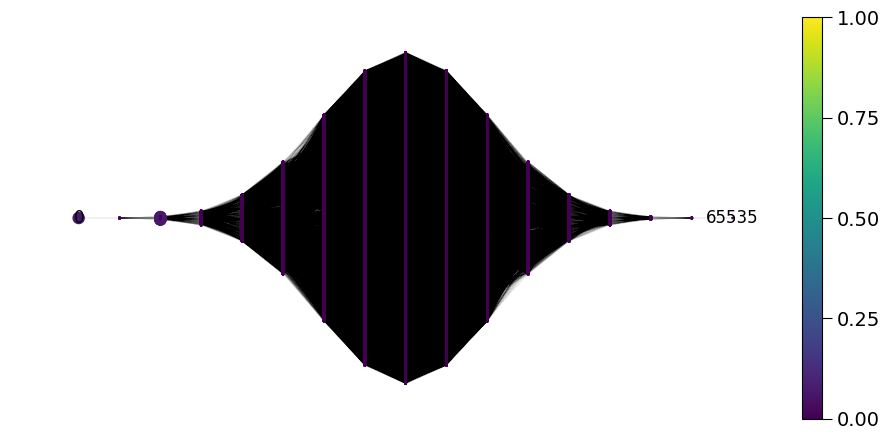

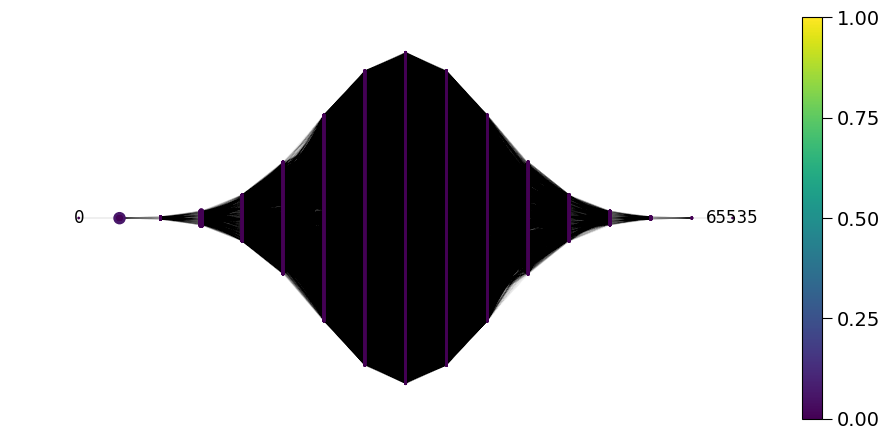

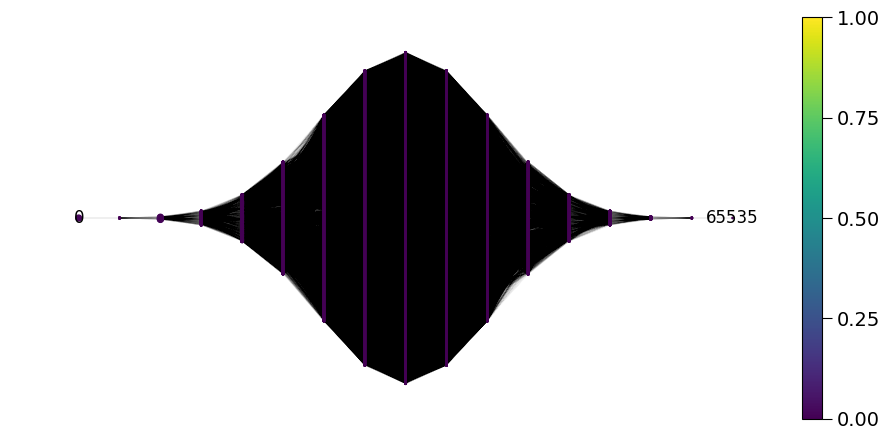

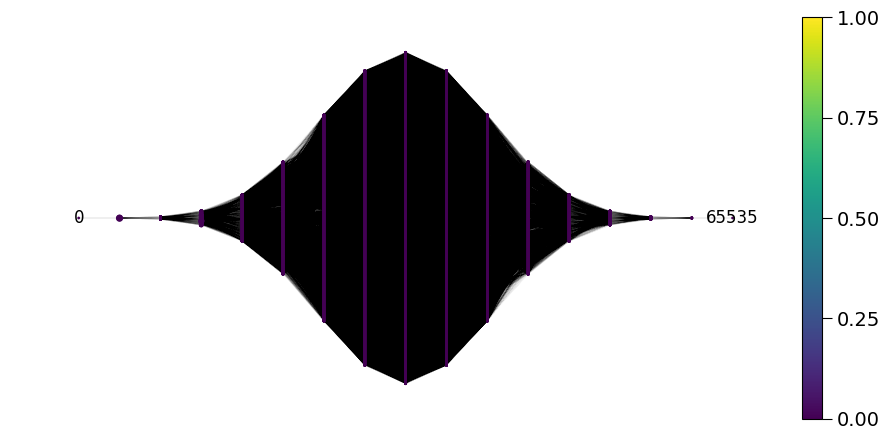

In [15]:
hpw.plot_probability_distribution(probs[0:5], graph=g, figsize=(9,4.5))

### Animating the quantum walk

In [16]:
#list_of_states = qw.simulate(range = (n//2,n//2+1), state = psi0)
#print(datetime.now())
#probs = qw.probability_distribution(psi_final)
hpw.plot_probability_distribution(probs, graph=g, animate=True, figsize=(9,4.5))
#print(datetime.now())